# Imports

In [2]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


## Load and Prepare Data

In [3]:

# URL to the dataset
url = "https://archive.ics.uci.edu/static/public/967/phiusiil+phishing+url+dataset.zip"

# Read the CSV file from the URL, ignoring the first column (index 0)
df = pd.read_csv(url, encoding="utf-8")
df = df.drop("FILENAME", axis=1)  # Column "FILENAME" can be ignored.
print("\nShape of data:", df.shape)
df.head()







Shape of data: (235795, 55)


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


# URLTitleMatchScore Regression Notebook

This notebook shows how to predict `URLTitleMatchScore` using other features, with proper training/testing split and leak prevention.

## Show correlation

In [4]:
# Keep numeric columns only
numeric_df = df.select_dtypes(include=[np.number])


print("Correlation with URLTitleMatchScore:")
print(numeric_df.corr()['URLTitleMatchScore'].sort_values(ascending=False))



Correlation with URLTitleMatchScore:
URLTitleMatchScore            1.000000
DomainTitleMatchScore         0.961008
CharContinuationRate          0.568560
URLSimilarityIndex            0.543969
label                         0.539419
HasSocialNet                  0.425394
HasTitle                      0.417060
HasCopyrightInfo              0.413144
HasDescription                0.398488
URLCharProb                   0.331182
HasSubmitButton               0.302893
IsResponsive                  0.297164
TLDLegitimateProb             0.296253
HasHiddenFields               0.265098
HasFavicon                    0.245452
Robots                        0.222834
IsHTTPS                       0.220749
Pay                           0.203851
NoOfJS                        0.199003
TLDLength                     0.169064
NoOfSelfRef                   0.161625
NoOfImage                     0.150345
LineOfCode                    0.146272
NoOfiFrame                    0.142916
NoOfExternalRef            

## Removing Leakage, High Correleation, and Irrelevant Features


In [5]:
leak_columns = [
    # 'Title',                  # UrlTitleMatchScore is derived from Title.
    'DomainTitleMatchScore',  # Extremely high correlation; direct overlap
    'label'                   # Phishing would cause leakage as it was the original target.
]

# Drop from feature matrix
numeric_df = numeric_df.drop(columns=leak_columns)

print("Remaining columns after dropping potential leaks:")
print(numeric_df.columns.tolist())

Remaining columns after dropping potential leaks:
['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']


## Prepare DF and Split into Test/Train

In [6]:
# Define X and y
X = numeric_df.drop('URLTitleMatchScore', axis=1)
y = numeric_df['URLTitleMatchScore']

# Drop known leaks
leak_columns = ['DomainTitleMatchScore', 'label']
X = X.drop(columns=[col for col in leak_columns if col in X.columns])

print("Remaining features:", X.columns.tolist())

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Remaining features: ['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']
Training samples: 188636
Testing samples: 47159


## Scale Features

In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Cross-Validation and Evaluation Metrics

We use **10-Fold Cross-Validation** (`KFold`) to get a reliable estimate of generalization performance.
Each fold trains on 90% of the training data and tests on 10%.

**Why 10 folds?**
- Good balance between bias and variance.
- Works well for medium-sized datasets.
- Uses as much data as possible for training each round.

**Evaluation metrics:**
- **MAE (Mean Absolute Error):** Average absolute difference between predicted and actual values.
- **RMSE (Root Mean Squared Error):** Penalizes larger errors more strongly.
- **R² (R-Squared):** Proportion of variance explained by the model.

Combining these metrics gives a better sense of how well the model performs.


In [8]:
# Define K-Fold CV
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Define scoring
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

# Task 2 Models

## Random Forest Regression

In [9]:

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

rf_scores = cross_validate(rf, X_train_scaled, y_train, cv=kf, scoring=scoring)

rf_results = {
    'MAE': -rf_scores['test_MAE'].mean(),
    'RMSE': -rf_scores['test_RMSE'].mean(),
    'R2': rf_scores['test_R2'].mean()
}

print(rf_results)


{'MAE': np.float64(9.905805997287588), 'RMSE': np.float64(21.722955278690662), 'R2': np.float64(0.8081511638274541)}


In [13]:
print(rf)

RandomForestRegressor(max_depth=10, random_state=42)


### Random Forest: Actual vs Predicted

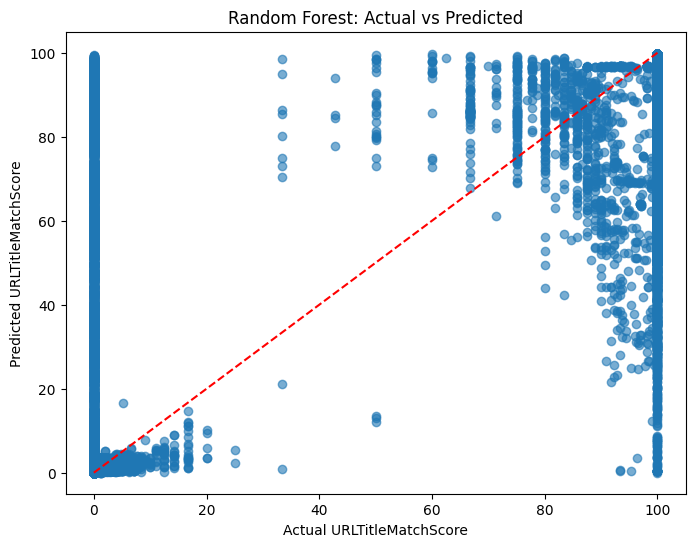

                       Feature    Importance
19  NoOfOtherSpecialCharsInURL  5.513282e-01
24                    HasTitle  2.071944e-01
3           URLSimilarityIndex  8.138454e-02
8                NoOfSubDomain  6.566168e-02
7                    TLDLength  2.442252e-02
5            TLDLegitimateProb  1.801312e-02
13            LetterRatioInURL  8.709537e-03
6                  URLCharProb  7.569095e-03
12            NoOfLettersInURL  6.670144e-03
4         CharContinuationRate  4.575401e-03
20       SpacialCharRatioInURL  4.302637e-03
1                 DomainLength  2.980719e-03
22                  LineOfCode  2.824071e-03
0                    URLLength  2.260195e-03
23           LargestLineLength  1.633049e-03
29            NoOfSelfRedirect  1.546617e-03
21                     IsHTTPS  1.293815e-03
15             DegitRatioInURL  1.116108e-03
47             NoOfExternalRef  9.256348e-04
45                 NoOfSelfRef  7.556815e-04
42                   NoOfImage  7.466166e-04
44        

In [14]:

rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual URLTitleMatchScore')
plt.ylabel('Predicted URLTitleMatchScore')
plt.title('Random Forest: Actual vs Predicted')
plt.show()

feature_names = X_train.columns

# Get importances
importances = rf.feature_importances_

# Make a DataFrame for easy sorting
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

## K-Nearest Neighbors Regression

In [20]:

knn = KNeighborsRegressor(n_neighbors=5)

knn_scores = cross_validate(knn, X_train_scaled, y_train, cv=kf, scoring=scoring)

knn_results = {
    'MAE': -knn_scores['test_MAE'].mean(),
    'RMSE': -knn_scores['test_RMSE'].mean(),
    'R2': knn_scores['test_R2'].mean()
}

print(knn_results)


{'MAE': np.float64(10.702598559250383), 'RMSE': np.float64(24.733844222116495), 'R2': np.float64(0.7512812891093427)}


## Support Vector Regression

In [ ]:

svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)

svr_scores = cross_validate(svr, X_train_scaled, y_train, cv=kf, scoring=scoring)

svr_results = {
    'MAE': -svr_scores['test_MAE'].mean(),
    'RMSE': -svr_scores['test_RMSE'].mean(),
    'R2': svr_scores['test_R2'].mean()
}

print(svr_results)


## Linear Regression

In [16]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr_scores = cross_validate(lr, X_train_scaled, y_train, cv=kf, scoring=scoring)

lr_results = {
    'MAE': -lr_scores['test_MAE'].mean(),
    'RMSE': -lr_scores['test_RMSE'].mean(),
    'R2': lr_scores['test_R2'].mean()
}

print(lr_results)

{'MAE': np.float64(25.424160710233856), 'RMSE': np.float64(31.49194759566135), 'R2': np.float64(0.596837184434833)}


# Model Comparison

      Random Forest        KNN         LR
MAE        9.905806  10.702599  25.424161
RMSE      21.722955  24.733844  31.491948
R2         0.808151   0.751281   0.596837


<Axes: title={'center': 'Regression Model Comparison'}>

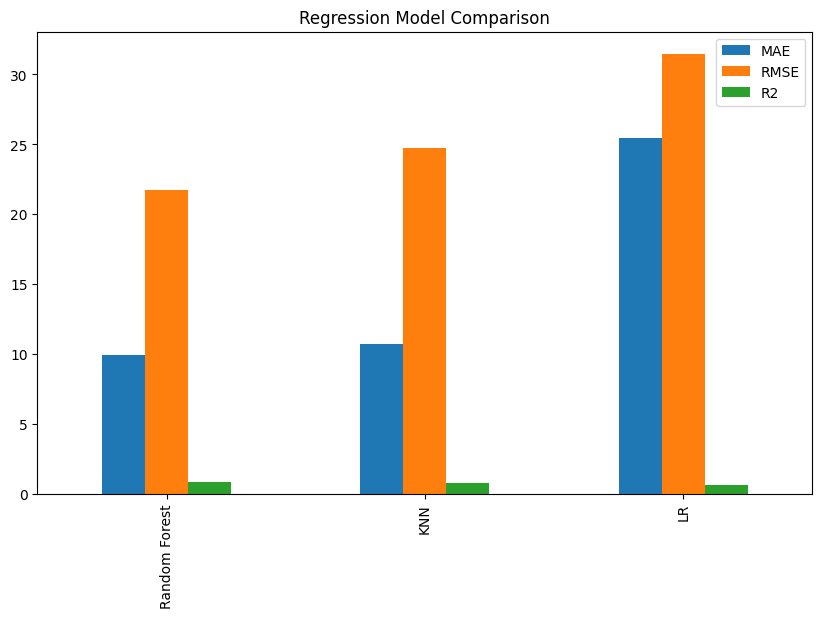

In [ ]:

comparison = pd.DataFrame({
    'Random Forest': rf_results,
    'KNN': knn_results,
    'LR': lr_results,
    'SVR': svr_results
})

print(comparison)

comparison.T.plot(kind='bar', figsize=(10,6), title='Regression Model Comparison')


## Comparing Models with Statistical Significance

This section compares the models using their cross-validation scores to check if the differences in performance are statistically significant at the 95% confidence level.  
A paired t-test is used to compare the mean scores fold by fold for each pair of models.

In [22]:
from scipy.stats import ttest_rel

# Get fold-wise R2 scores
rf_r2_scores = rf_scores['test_R2']
knn_r2_scores = knn_scores['test_R2']
lr_r2_scores = lr_scores['test_R2']

# Define pairs to compare
pairs = [
    ('Random Forest', rf_r2_scores, 'KNN', knn_r2_scores),
    ('Random Forest', rf_r2_scores, 'Linear Regression', lr_r2_scores),
    ('KNN', knn_r2_scores, 'Linear Regression', lr_r2_scores)
]

# Run paired t-tests for each pair
for name1, scores1, name2, scores2 in pairs:
    t_stat, p_value = ttest_rel(scores1, scores2)
    print(f"Comparing {name1} vs {name2}:")
    print(f"  {name1} mean R2: {scores1.mean():.4f}")
    print(f"  {name2} mean R2: {scores2.mean():.4f}")
    print(f"  T-statistic: {t_stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  The difference is statistically significant at the 95% confidence level.\n")
    else:
        print("  The difference is not statistically significant at the 95% confidence level.\n")


Comparing Random Forest vs KNN:
  Random Forest mean R2: 0.8082
  KNN mean R2: 0.7513
  T-statistic: 54.8460
  P-value: 0.0000
  The difference is statistically significant at the 95% confidence level.

Comparing Random Forest vs Linear Regression:
  Random Forest mean R2: 0.8082
  Linear Regression mean R2: 0.5968
  T-statistic: 79.9404
  P-value: 0.0000
  The difference is statistically significant at the 95% confidence level.

Comparing KNN vs Linear Regression:
  KNN mean R2: 0.7513
  Linear Regression mean R2: 0.5968
  T-statistic: 45.7435
  P-value: 0.0000
  The difference is statistically significant at the 95% confidence level.



## Key Findings

The paired t-tests show that the differences in R² scores between Random Forest, KNN, and Linear Regression are statistically significant at the 95% confidence level.

- Random Forest has the highest mean R², explaining the most variance in the target.
- KNN performs slightly worse than Random Forest but better than Linear Regression.
- Linear Regression has the lowest mean R², indicating that a simple linear approach does not capture the relationships as well as the more flexible models.

These results are expected because Random Forest can model complex, non-linear relationships and feature interactions, while Linear Regression is limited to a straight-line fit. KNN can handle non-linearity too but may be more sensitive to data structure and scaling.

Overall, Random Forest is the best-performing model for predicting `URLTitleMatchScore` based on this analysis.


# Model Analysis and Real-World Use

## Which Features Matter Most

We used the Random Forest’s built-in feature importance scores to find out which attributes are most useful for predicting the `URLTitleMatchScore`.  
This method is appropriate because it shows how much each feature helps reduce prediction error when the model splits decision trees.

Based on the results, some of the most important features were:
- **NoOfOtherSpecialCharsInURL**: Extra special characters can make URLs look suspicious.
- **HasTitle**: Whether the page has a title that matches the URL.
- **URLSimilarityIndex**: Shows how similar the URL is to expected patterns.
- **NoOfSubDomain**: Extra subdomains can hide malicious intent or make a fake site look legitimate.

We dropped `DomainTitleMatchScore`, `Title`, and `label` from the predictors to avoid data leakage, since these could directly reveal or influence the target.

## Why Do These Features Matter

These attributes help detect signs that a URL may be trying to look like a trusted site:
- Phishing sites often include extra special characters or subdomains to trick users.
- They mimic known titles and structures to seem legitimate.
- The similarity index captures how closely a suspicious URL matches a real one.

If we were doing classification instead of regression, these same features would likely still be important to distinguish phishing from legitimate websites.

## Usefulness for Interested Parties

This kind of model could help security teams, email providers, or web browsers automatically detect and block suspicious URLs before users interact with them.  
It can reduce the workload for manual review, lower the risk of successful phishing attempts, and improve user safety by providing early warnings.

## Measuring and Improving the Model
- Test how many phishing URLs are blocked vs missed.
- Retrain with updated data regularly as attackers change strategies.
- Add more data like page content or SSL info for better predictions.

## Deployment
Run the model as an API or integrate it into a security pipeline. Monitor its performance and update as needed.
